# Telugu → English Transliteration

In [ ]:
%%capture
!pip install datasets torch scikit-learn

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import random
import json
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")

c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
PyTorch: 2.11.0+cpu


## 1. Load Dataset

In [3]:
ds = load_dataset("ramgopal-reddy/Telugu_to_English_Transliteration_Dakshina")["train"]
print(f"Dataset size: {len(ds)}")
print(ds[0])

telugu_words  = ds["native_word"]
english_words = ds["english_word"]

Dataset size: 50927
{'unique_identifier': 'tel1', 'native_word': 'దుర్మార్గపు', 'english_word': 'dhurmaargapu', 'source': 'Dakshina'}


## 2. Vocabulary

In [4]:
SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def build_vocab(words):
    chars = set()
    for word in words:
        chars.update(list(word))
    char2idx = {c: i + len(SPECIAL_TOKENS) for i, c in enumerate(sorted(chars))}
    for i, token in enumerate(SPECIAL_TOKENS):
        char2idx[token] = i
    idx2char = {i: c for c, i in char2idx.items()}
    return char2idx, idx2char

tel_char2idx, tel_idx2char = build_vocab(telugu_words)
eng_char2idx, eng_idx2char = build_vocab(english_words)

print(f"Telugu vocab size : {len(tel_char2idx)}")
print(f"English vocab size: {len(eng_char2idx)}")

max_tel = max(len(w) for w in telugu_words)
max_eng = max(len(w) for w in english_words)
MAX_SRC_LEN = max_tel + 2
MAX_TRG_LEN = max_eng + 2
print(f"MAX_SRC_LEN={MAX_SRC_LEN}, MAX_TRG_LEN={MAX_TRG_LEN}")

Telugu vocab size : 66
English vocab size: 30
MAX_SRC_LEN=22, MAX_TRG_LEN=27


## 3. Encoding + Data Augmentation

In [5]:
def encode(word, char2idx, max_len):
    seq = [SOS_IDX]
    for c in word:
        seq.append(char2idx.get(c, UNK_IDX))
    seq.append(EOS_IDX)
    seq = seq[:max_len]
    seq += [PAD_IDX] * (max_len - len(seq))
    return seq

def augment(word, swap_p=0.05, drop_p=0.03):
    """
    Light character-level augmentation on Telugu input.
    - swap_p: probability of swapping two adjacent characters
    - drop_p: probability of dropping a character (skip on short words)
    Applied only during training; inference gets the clean word.
    """
    chars = list(word)
    # Random adjacent swap
    if len(chars) > 2 and random.random() < swap_p:
        i = random.randint(0, len(chars) - 2)
        chars[i], chars[i + 1] = chars[i + 1], chars[i]
    # Random drop (keep at least 2 chars)
    if len(chars) > 3 and random.random() < drop_p:
        i = random.randint(0, len(chars) - 1)
        chars.pop(i)
    return ''.join(chars)

# Sanity check
print("Original:", telugu_words[0], "->", english_words[0])
print("Encoded src:", encode(telugu_words[0], tel_char2idx, MAX_SRC_LEN))
print("Encoded trg:", encode(english_words[0], eng_char2idx, MAX_TRG_LEN))

Original: దుర్మార్గపు -> dhurmaargapu
Encoded src: [1, 35, 56, 44, 65, 42, 53, 44, 65, 21, 38, 56, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded trg: [1, 7, 11, 24, 21, 16, 4, 4, 21, 10, 4, 19, 24, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Create Feature Vectors for Words

encode() gives integer sequences.

In [6]:
import numpy as np

def vectorize_words(words, char2idx, max_len):
    vectors = []
    for w in words:
        vectors.append(encode(w, char2idx, max_len))
    return np.array(vectors)

X = vectorize_words(telugu_words, tel_char2idx, MAX_SRC_LEN)

print(X.shape)

(50927, 22)


K-Means Clustering

This groups similar Telugu words together.

In [7]:
from sklearn.cluster import KMeans

n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X)

# Show grouped words
for i in range(n_clusters):
    print(f"\nCluster {i}")
    for word in np.array(telugu_words)[clusters == i][:2]:
        print(word)


Cluster 0
మన్నించమని
గడిపేశారు

Cluster 1
మైత్రి
నేటికీ

Cluster 2
చూపరులకు
ముఖ్యుడు

Cluster 3
దుర్మార్గపు
దర్శనమిస్తాయి

Cluster 4
తప్పును
వెహికల్


Hierarchical Clustering + Dendrogram

This is excellent for visualization.

c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3093 (\N{TELUGU LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Telugu natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3147 (\N{TELUGU VOWEL SIGN OO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3149 (\N{TELUGU SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\IPython\core\pylabtools.py:170: 

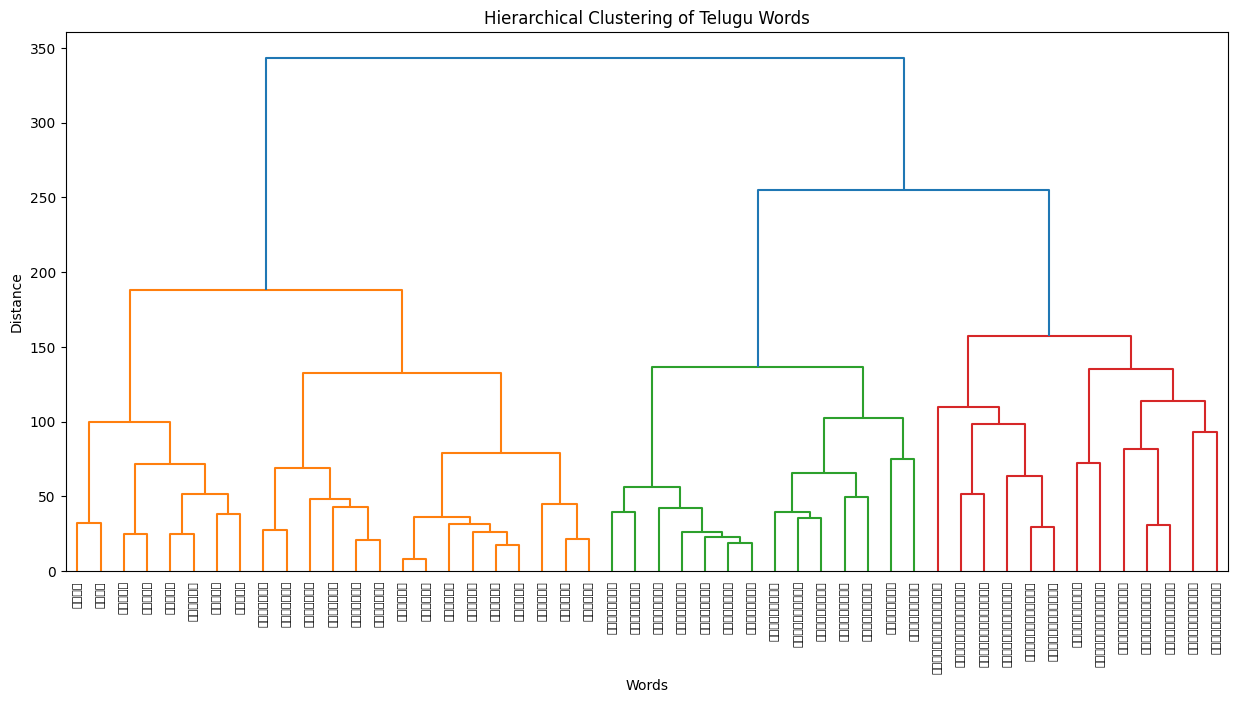

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Use smaller subset for readability
sample_X = X[:50]
sample_words = telugu_words[:50]

Z = linkage(sample_X, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    Z,
    labels=sample_words,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Telugu Words")
plt.xlabel("Words")
plt.ylabel("Distance")

plt.show()

PCA Visualization

Reduce dimensions for plotting clusters.

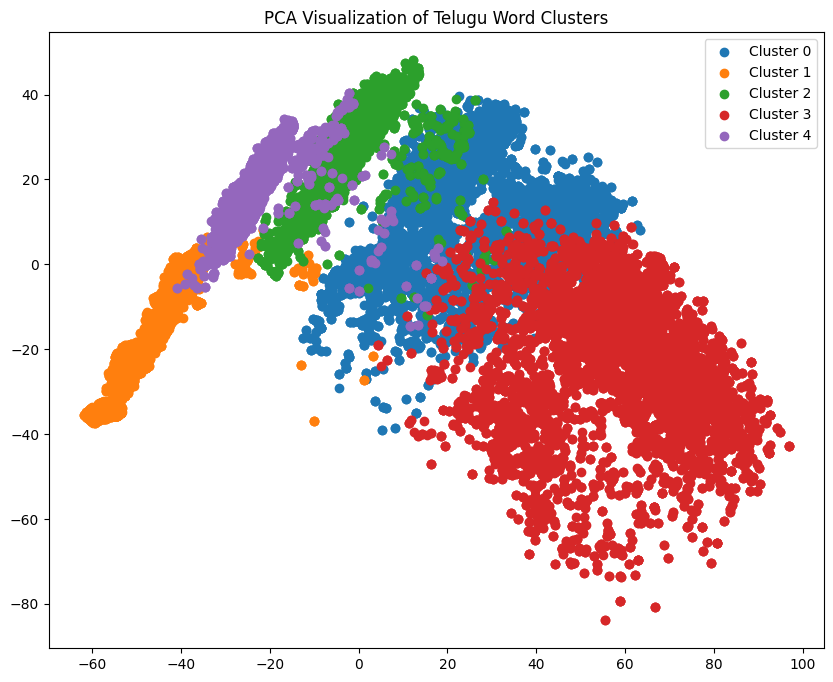

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

for i in range(n_clusters):
    pts = X_2d[clusters == i]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {i}")

plt.legend()
plt.title("PCA Visualization of Telugu Word Clusters")
plt.show()

Better Features Using Character TF-IDF

Raw integer encoding is weak for clustering.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 4)
)

X_tfidf = vectorizer.fit_transform(telugu_words)

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

In [12]:
%%capture
!pip install umap-learn plotly networkx

TF-IDF Character Vectors

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2,4),
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(telugu_words)

print(X_tfidf.shape)

(50927, 5000)


Reduce Dimensions with UMAP

UMAP is MUCH better than PCA for embeddings.

In [14]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = reducer.fit_transform(X_tfidf)

print(X_umap.shape)

c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\rishi\Desktop\Projects\TransLetration\.venv\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is 

(50927, 2)


Interactive Plotly Space

In [15]:
!pip install nbformat>=4.2.0 ipython

In [16]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    'x': X_umap[:,0],
    'y': X_umap[:,1],
    'word': english_words
})

fig = px.scatter(
    df,
    x='x',
    y='y',
    hover_name='word',
    title='Interactive Telugu Word Embedding Space'
)

fig.update_traces(marker=dict(size=8))

fig.show()